# 🔎 Data Preview & Signal Structure Analysis

This report presents an Exploratory Data Analysis (EDA) of the EEG Eye State dataset, composed of 14 EEG channel measurements and a binary target indicating eye state (0 = open, 1 = closed). The goal is to assess data structure and quality, understand target distribution, and inspect feature behavior (distributions, outliers, correlations) to inform subsequent preprocessing and modeling decisions.


Examining the first few rows (`head`) reveals three critical technical insights that will guide our preprocessing strategy:

1.  **DC Offset (Baseline Bias):**
    The raw EEG values do not oscillate around zero (as expected in pure electrical signals) but are shifted around a baseline of **~4000-4600**.
    *   *Implication:* This indicates a hardware DC offset. For distance-based algorithms (like kNN or SVM) and Neural Networks, it is mandatory to **center** or **standardize** the data (e.g., `StandardScaler`), otherwise, the model will learn the bias rather than the signal variations.

2.  **Short-Term Stability (Autocorrelation):**
    Values change minimally between consecutive rows (e.g., AF3 moves from 4329 to 4324).
    *   *Implication:* This confirms the high sampling rate (~128Hz). Adjacent samples are strongly **autocorrelated**, meaning we cannot treat them as independent and identically distributed (i.i.d.) observations. This reinforces the need for **time-series validation** (avoiding random shuffle split) to prevent data leakage.

3.  **Target Variable:**
    The `eyeDetection` column is a binary integer (0/1), confirming this is a standard **binary classification task**.



What do the feature columns represent?
Each feature (column) corresponds to the electrical activity of the brain measured at a specific EEG electrode, following the international 10–20 system.

**EEG Feature Columns**

| Column | Brain region | What it represents |
| :--- | :--- | :--- |
| AF3 | Anterior frontal (left) | Attention, focus |
| AF4 | Anterior frontal (right) | Attention, decision making |
| F3 | Frontal (left) | Thinking, memory |
| F4 | Frontal (right) | Cognitive control |
| F7 | Frontal lateral (left) | Emotion processing |
| F8 | Frontal lateral (right) | Emotion processing |
| FC5 | Fronto-central (left) | Motor planning |
| FC6 | Fronto-central (right) | Motor planning |
| T7 | Temporal (left) | Auditory processing |
| T8 | Temporal (right) | Auditory processing |
| P7 | Parietal (left) | Spatial awareness |
| P8 | Parietal (right) | Spatial awareness |
| O1 | Occipital (left) | Visual processing |
| O2 | Occipital (right) | Visual processing |


**✅ Data Integrity Check: No Missing Values**

**Key Finding:** The dataset shows **0% missing values** across all 15 features (14 EEG channels + target).

**Why this matters:**
*   **Positive sign:** This suggests a **controlled laboratory recording** with continuous electrode contact throughout the 117-second session. In real-world EEG data, missing values are common due to:
    *   Electrode detachment
    *   Artifacts leading to signal rejection
    *   Pre-processing filters removing corrupted segments
    
*   **Implication for preprocessing:**
    *   We can skip imputation strategies (no need for mean/median filling or advanced techniques like KNN imputation).
    *   However, we must remain vigilant about **extreme outliers** (which we already noticed in the `describe()` output). Zero missing values doesn't guarantee zero noise.

**Data types:** All features are correctly stored as `float64`, which is suitable for numerical modeling. The target (`eyeDetection`) could be converted to `int8` or `category` to save memory, but for a dataset of ~15K rows, this optimization is negligible.





[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



First 5 rows of features (EEG data):
       AF3       F7       F3      FC5       T7       P7       O1       O2  \
0  4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1  4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2  4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3  4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4  4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   

        P8       T8      FC6       F4       F8      AF4  
0  4222.05  4238.46  4211.28  4280.51  4635.90  4393.85  
1  4210.77  4226.67  4207.69  4279.49  4632.82  4384.10  
2  4207.69  4222.05  4206.67  4282.05  4628.72  4389.23  
3  4217.44  4235.38  4210.77  4287.69  4632.31  4396.41  
4  4210.77  4244.10  4212.82  4288.21  4632.82  4398.46  

First 5 rows of target (eye state):
   eyeDetection
0             0
1             0
2             0
3             0
4             0

PREPROCESSING: DC

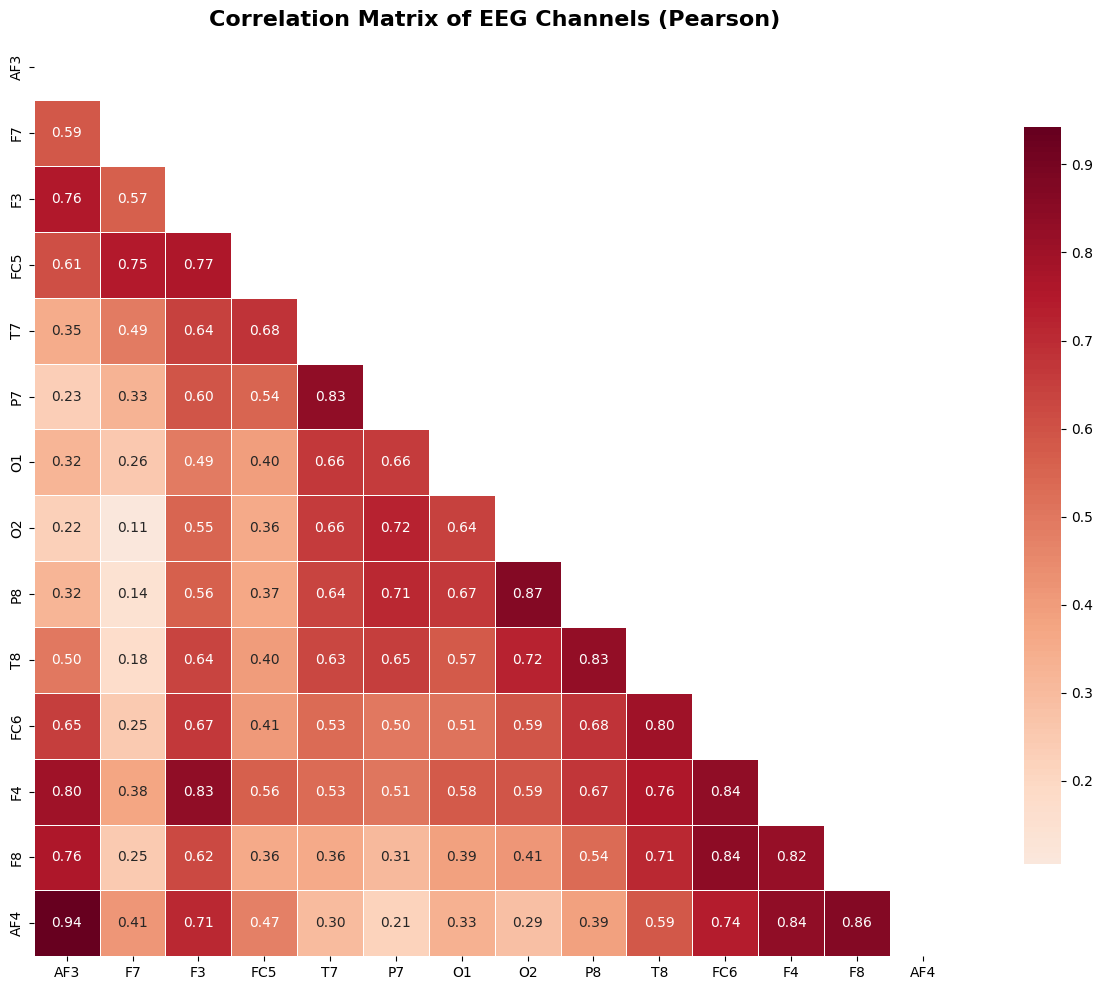


Strong Correlations (|r| > 0.7):
Channel1 Channel2  Correlation
     AF3      AF4        0.943
      O2       P8        0.867
      F8      AF4        0.864
     FC6       F8        0.843
      F4      AF4        0.838
     FC6       F4        0.836
      T7       P7        0.835
      F3       F4        0.833
      P8       T8        0.828
      F4       F8        0.823
      T8      FC6        0.801
     AF3       F4        0.797
      F3      FC5        0.765
      T8       F4        0.764
     AF3       F8        0.758
     AF3       F3        0.755
      F7      FC5        0.750
     FC6      AF4        0.741
      O2       T8        0.724
      P7       O2        0.721
      T8       F8        0.714
      F3      AF4        0.708
      P7       P8        0.708

3. CORRELATION WITH TARGET VARIABLE


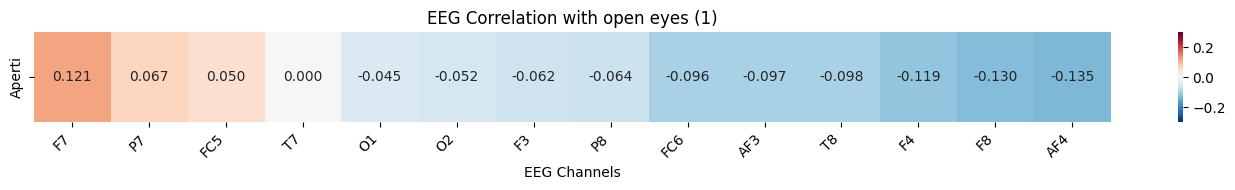

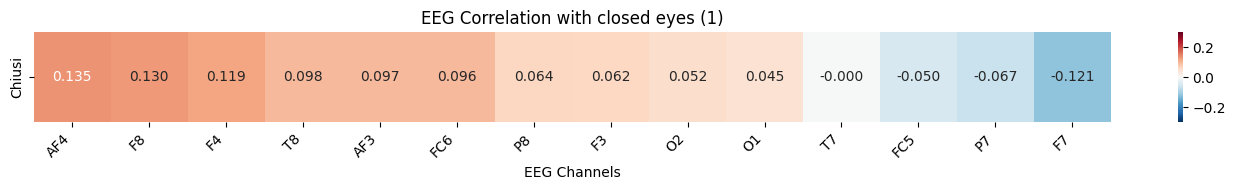

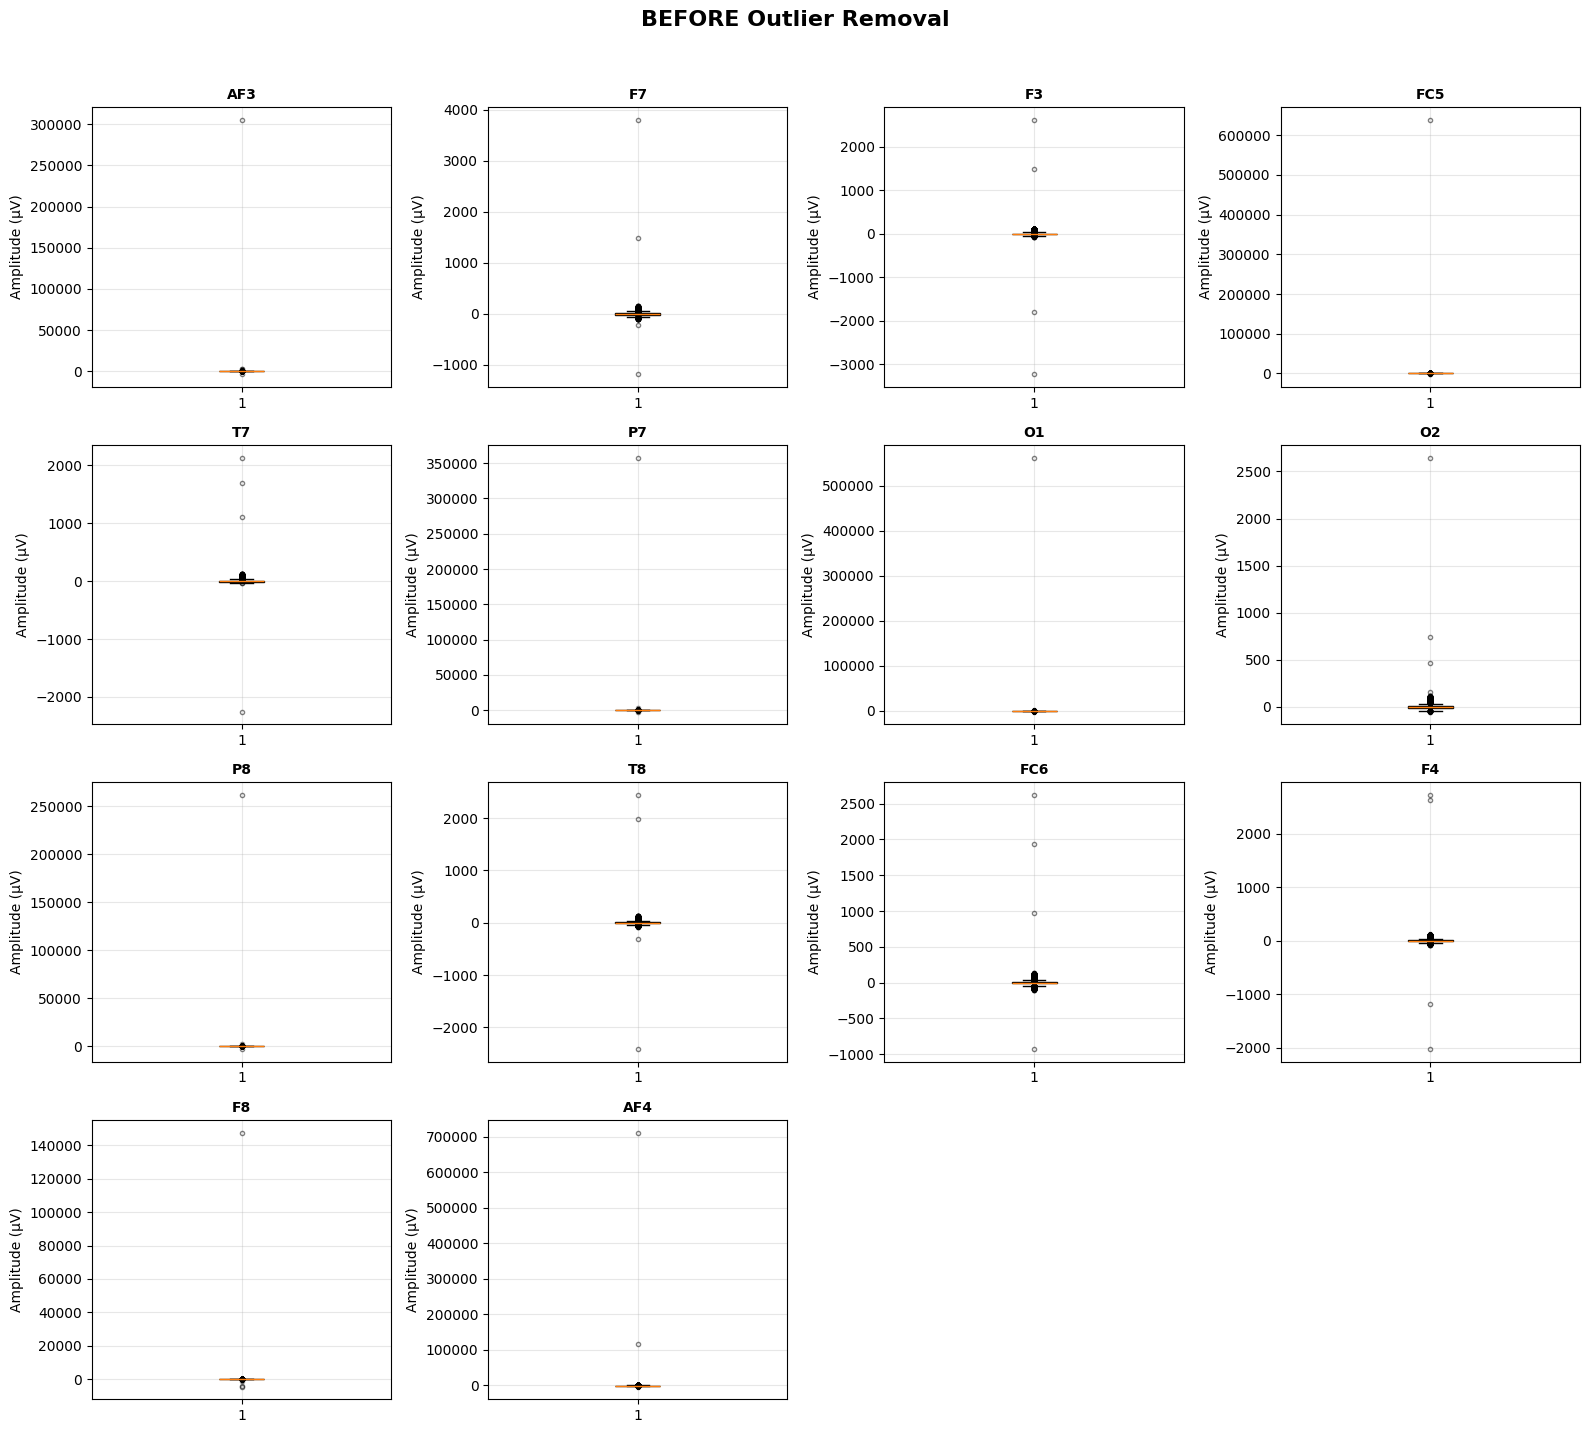

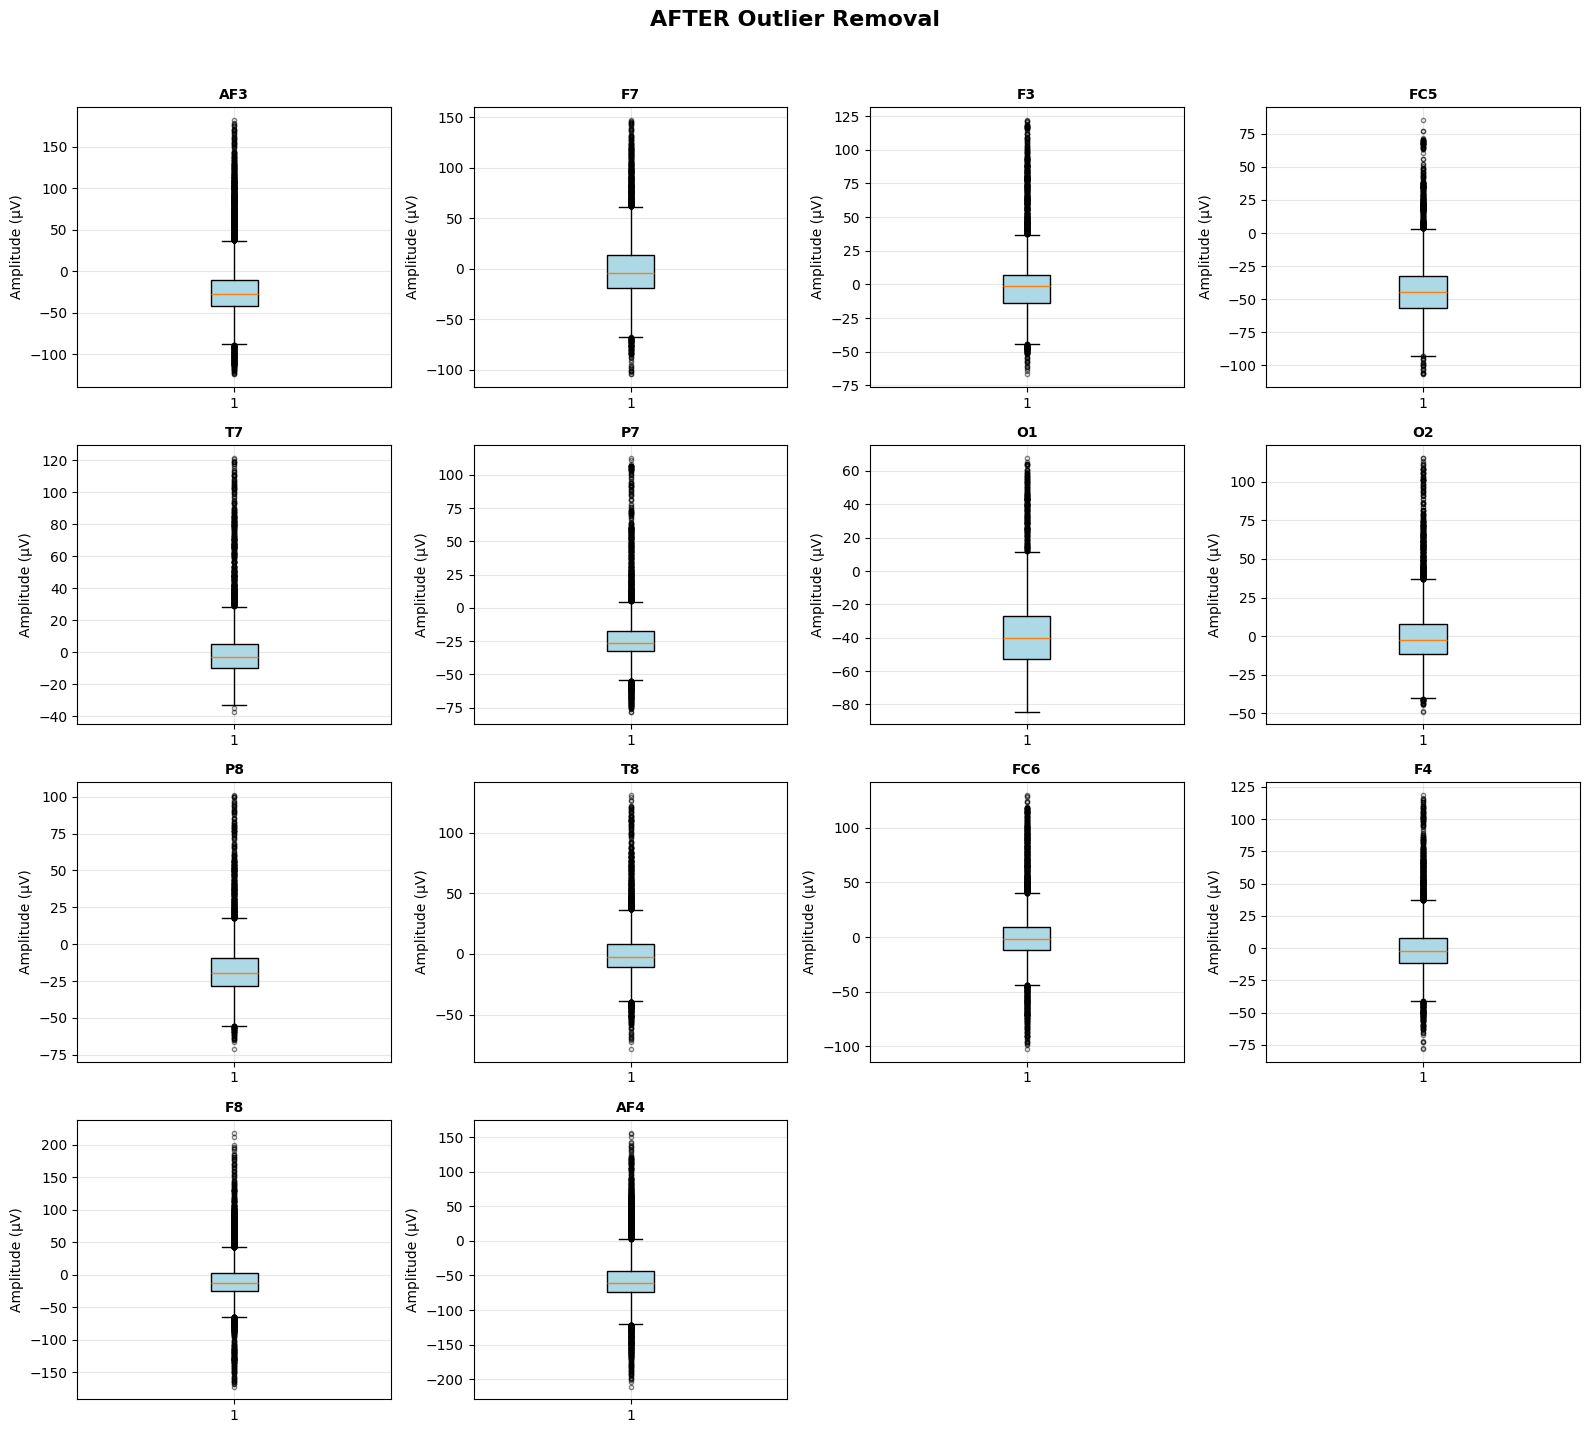


--------------------------------------------------------------------------------
DESCRIPTIVE ANALYSIS OF RESIDUAL OUTLIERS (IQR vs Z-SCORE)
--------------------------------------------------------------------------------
Channel IQR_count IQR_% Z_count   Z_% IQR_bounds
    AF3      1481 9.89%     341 2.28%  [-88, 37]
     F7       706 4.71%     236 1.58%  [-67, 62]
     F3       821 5.48%     354 2.36%  [-45, 38]
    FC5       597 3.99%     290 1.94%   [-93, 4]
     T7       723 4.83%     331 2.21%  [-33, 29]
     P7      1061 7.08%     306 2.04%   [-55, 5]
     O1       344 2.30%     249 1.66%  [-91, 12]
     O2       605 4.04%     292 1.95%  [-41, 37]


In [1]:
# Install required package for accessing UCI datasets - MIO
!pip install ucimlrepo

# Import necessary libraries
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis, shapiro
# Fetch the EEG Eye State dataset (ID: 264)
eeg_eye_state = fetch_ucirepo(id=264)


# Extract features and targets as pandas DataFrames
X = eeg_eye_state.data.features  # EEG features (14 columns)
y = eeg_eye_state.data.targets   # Eye state labels (0=open, 1=closed)

# Preview the data
print("\nFirst 5 rows of features (EEG data):")
print(X.head())
print("\nFirst 5 rows of target (eye state):")
print(y.head())

# ============================================================
# DC OFFSET REMOVAL (MEAN CENTERING) + OUTLIER REMOVAL
# ============================================================

print("\n" + "=" * 80)
print("PREPROCESSING: DC OFFSET REMOVAL AND OUTLIER HANDLING")
print("=" * 80)

# Copy original data
X_raw = X.copy()
y_raw = y  # y is already fine (Series or array)

# -------------------------
# STEP 1 – DC OFFSET REMOVAL
# -------------------------

print("\nSTEP 1 – DC OFFSET REMOVAL (Mean Centering)")
print("We subtract the mean of each EEG channel to remove the hardware DC offset.")

# Compute channel-wise means (DC offsets)
dc_offsets = X_raw.mean(axis=0)

print("\nChannel means BEFORE centering (DC offsets, first 5):")
print(dc_offsets.head())

# Mean centering
X_centered = X_raw - dc_offsets

print("\nValue range BEFORE centering: "
      f"[{X_raw.min().min():.2f}, {X_raw.max().max():.2f}] μV")
print("Value range AFTER centering:  "
      f"[{X_centered.min().min():.2f}, {X_centered.max().max():.2f}] μV")

print("\nChannel means AFTER centering (should be ~0, first 5):")
print(X_centered.mean(axis=0).head())

# -------------------------
# STEP 2 – OUTLIER DETECTION & REMOVAL
# -------------------------

print("\n" + "-" * 80)
print("STEP 2 – OUTLIER DETECTION AND REMOVAL")
print("-" * 80)

# Threshold for extreme EEG values (μV)
threshold = 500

print(f"\nOutlier threshold: ±{threshold} μV")

# Boolean mask: rows containing at least one extreme value
mask_with_outliers = (X_centered.abs() > threshold).any(axis=1)
rows_with_outliers = mask_with_outliers.sum()
total_rows = len(X_centered)

print(f"\nRows with outliers (>|{threshold}| μV): "
      f"{rows_with_outliers} / {total_rows} "
      f"({rows_with_outliers/total_rows*100:.3f}%)")

# Keep only rows WITHOUT extreme outliers
mask_clean = ~mask_with_outliers
X_clean = X_centered[mask_clean].copy()
y_clean = y_raw[mask_clean]

print(f"Rows AFTER outlier removal: {len(X_clean)} "
      f"({len(X_clean)/total_rows*100:.2f}% retained)")

# ============================================================
# FROM HERE ON, WE USE THE CLEAN DATA
# ============================================================


# Create a complete DataFrame using CLEANED data
df = X_clean.copy()
df['eye_state'] = y_clean

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset Shape: {df.shape}")
print(f"Number of EEG Channels: {len(df.columns) - 1}")
print(f"Total Observations: {len(df)}")
print(f"Chronological Recording Duration: 117 seconds")
print(f"Approximate Sampling Rate: {len(df)/117:.1f} Hz")


#basic data profiling
print("\n" + "=" * 80)
print("1. BASIC DATA PROFILING")
print("=" * 80)

# Check data types and missing values
print("\nData Types and Missing Values:")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df)

#basic statistic
print("\nDescriptive Statistics:")
print(df.describe().T)

#define eeg_channels
eeg_channels = X_clean.columns.tolist()


print("\n" + "=" * 80)
print("2. CORRELATION ANALYSIS BETWEEN EEG CHANNELS")
print("=" * 80)

# Calculate correlation matrix
corr_matrix = df[eeg_channels].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of EEG Channels (Pearson)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Find strong correlations
strong_corr_threshold = 0.7
strong_correlations = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > strong_corr_threshold:
            strong_correlations.append({
                'Channel1': corr_matrix.columns[i],
                'Channel2': corr_matrix.columns[j],
                'Correlation': round(corr_value, 3)
            })

strong_corr_df = pd.DataFrame(strong_correlations)
print(f"\nStrong Correlations (|r| > {strong_corr_threshold}):")
if len(strong_corr_df) > 0:
    print(strong_corr_df.sort_values('Correlation', key=abs, ascending=False).to_string(index=False))
else:
    print("No strong correlations found (|r| < 0.7).")


print("\n" + "=" * 80)
print("3. CORRELATION WITH TARGET VARIABLE")
print("=" * 80)

# CORRELAZIONE CON OCCHI APERTI (target = eye_state == 0)
corr_open = df[eeg_channels].corrwith(df['eye_state'] == 0).sort_values(ascending=False)

plt.figure(figsize=(14, 2))
sns.heatmap(corr_open.values.reshape(1,-1), annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, xticklabels=corr_open.index, yticklabels=['Aperti'],
            vmin=-0.3, vmax=0.3)
plt.title('EEG Correlation with open eyes (1)')
plt.xlabel('EEG Channels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# CORRELAZIONE CON OCCHI CHIUSI (target = eye_state == 1)
corr_closed = df[eeg_channels].corrwith(df['eye_state'] == 1).sort_values(ascending=False)

plt.figure(figsize=(14, 2))
sns.heatmap(corr_closed.values.reshape(1,-1), annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, xticklabels=corr_closed.index, yticklabels=['Chiusi'],
            vmin=-0.3, vmax=0.3)
plt.title('EEG Correlation with closed eyes (1)')
plt.xlabel('EEG Channels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -------------------------
# STEP 3 – VISUAL INSPECTION (BOXPLOTS BEFORE/AFTER)
# -------------------------
# [boxplot function]
# Helper function to plot boxplots in a 4x4 grid
def plot_boxplots(data, title):
    
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.ravel()
    
    for i, channel in enumerate(eeg_channels):
        ax = axes[i]
        
        bp = ax.boxplot(data[channel], vert=True, patch_artist=True)
        
        # Style
        plt.setp(bp['fliers'], marker='o', color='red', alpha=0.5, markersize=3)
        plt.setp(bp['boxes'], facecolor='lightblue')
        
        ax.set_title(channel, fontsize=10, fontweight='bold')
        ax.set_ylabel('Amplitude (μV)')
        ax.grid(True, alpha=0.3)
    
    
    for j in range(len(eeg_channels), 16):
        axes[j].set_visible(False)
    
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_boxplots(X_centered, "BEFORE Outlier Removal")
plot_boxplots(X_clean, "AFTER Outlier Removal")

# -------------------------
# STEP 4 – DESCRIPTIVE OUTLIER ANALYSIS (IQR & Z-SCORE)
# -------------------------
print("\n" + "-" * 80)
print("DESCRIPTIVE ANALYSIS OF RESIDUAL OUTLIERS (IQR vs Z-SCORE)")
print("-" * 80)

# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Function to detect outliers using Z-score method
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column]))
    outliers = data[z_scores > threshold]
    return outliers

outlier_summary = pd.DataFrame(columns=['Channel', 'IQR_count', 'IQR_%', 'Z_count', 'Z_%', 'IQR_bounds'])

for channel in eeg_channels[:8]:
    iqr_outliers, lower_b, upper_b = detect_outliers_iqr(X_clean, channel)
    z_outliers = detect_outliers_zscore(X_clean, channel)
    
    outlier_summary = pd.concat([outlier_summary, pd.DataFrame([{
        'Channel': channel,
        'IQR_count': len(iqr_outliers),
        'IQR_%': f"{len(iqr_outliers)/len(X_clean)*100:.2f}%",
        'Z_count': len(z_outliers),
        'Z_%': f"{len(z_outliers)/len(X_clean)*100:.2f}%",
        'IQR_bounds': f'[{lower_b:.0f}, {upper_b:.0f}]'
    }])], ignore_index=True)

print(outlier_summary.to_string(index=False))


# EEG channels distribution



1. TARGET VARIABLE ANALYSIS
Eye Open (0): 8254 samples (55.11%)
Eye Closed (1): 6722 samples (44.89%)
Class Imbalance Ratio (Open/Closed): 1.228


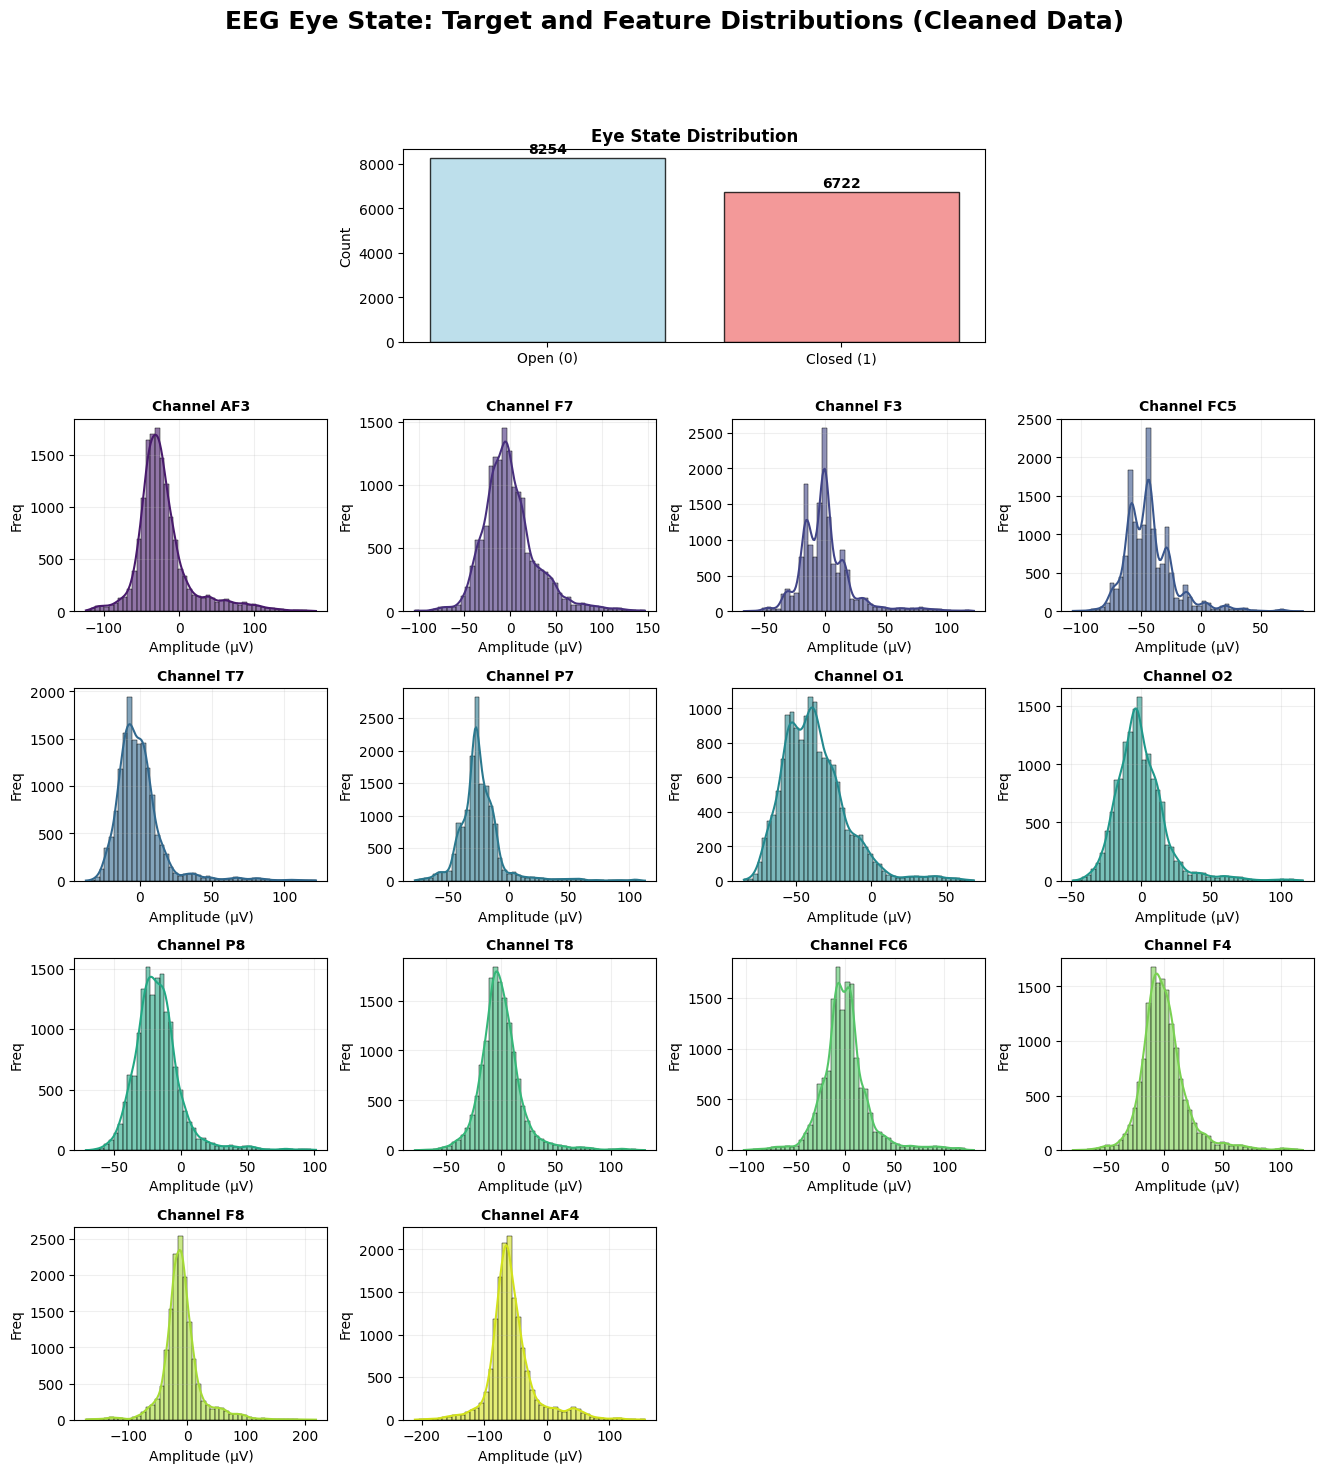

In [2]:
# ============================================================
# TARGET & DISTRIBUTION ANALYSIS (UNIFIED)
# ============================================================

print("\n" + "=" * 80)
print("1. TARGET VARIABLE ANALYSIS")
print("=" * 80)

# Define distribution
eye_state_counts = df['eye_state'].value_counts().sort_index()
eye_state_percent = df['eye_state'].value_counts(normalize=True) * 100
imbalance_ratio = eye_state_counts[0] / eye_state_counts[1]

print(f"Eye Open (0): {eye_state_counts[0]} samples ({eye_state_percent[0]:.2f}%)")
print(f"Eye Closed (1): {eye_state_counts[1]} samples ({eye_state_percent[1]:.2f}%)")
print(f"Class Imbalance Ratio (Open/Closed): {imbalance_ratio:.3f}")

# Layout
fig = plt.figure(figsize=(16, 20))
gs = fig.add_gridspec(6, 4, hspace=0.4, wspace=0.3)

# --- Subplot for the Target 
ax_target = fig.add_subplot(gs[0, 1:3])
colors_target = ['lightblue', 'lightcoral']
bars = ax_target.bar(['Open (0)', 'Closed (1)'], eye_state_counts.values, color=colors_target, edgecolor='black', alpha=0.8)
ax_target.set_title('Eye State Distribution', fontsize=12, fontweight='bold')
ax_target.set_ylabel('Count')

# label
for bar in bars:
    height = bar.get_height()
    ax_target.text(bar.get_x() + bar.get_width()/2., height + 100, f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# --- Subplots for EEG Channels
eeg_channels = [col for col in df.columns if col != 'eye_state']
colors_eeg = sns.color_palette("viridis", len(eeg_channels))

# Start from row 1
for i, channel in enumerate(eeg_channels):
    row = (i // 4) + 1
    col = i % 4
    ax = fig.add_subplot(gs[row, col])
    
    sns.histplot(x=df[channel], bins=50, kde=True, color=colors_eeg[i], ax=ax, alpha=0.6)
    
    ax.set_title(f"Channel {channel}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Amplitude (μV)")
    ax.set_ylabel("Freq")
    ax.grid(True, alpha=0.2)

plt.suptitle('EEG Eye State: Target and Feature Distributions (Cleaned Data)', 
             fontsize=18, fontweight='bold', y=0.95)


for j in range(len(eeg_channels), 20):
    row = (j // 4) + 1
    if row < 6:
        col = j % 4


plt.show()

# MEAN EEG AMPLITUDE PER CHANNEL BY EYE STATE

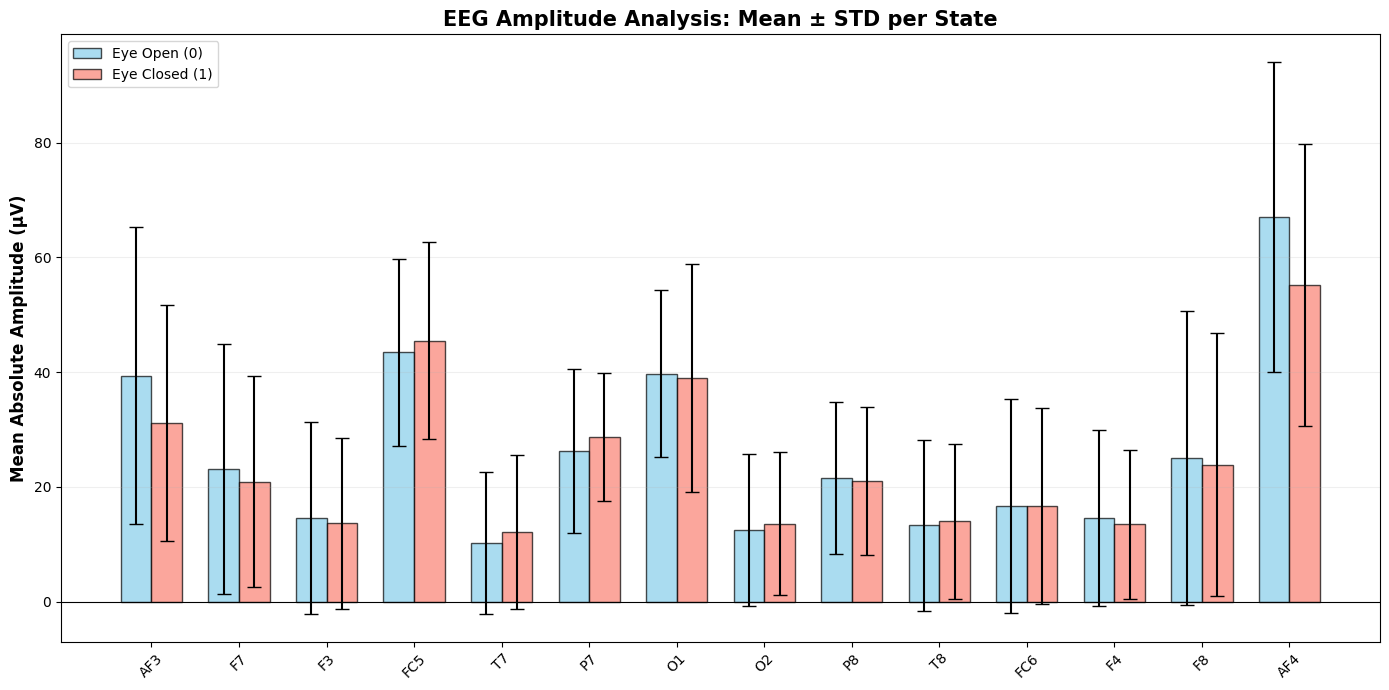

In [3]:
# 1

df_abs = df.copy()
for ch in eeg_channels:
    df_abs[ch] = df_abs[ch].abs()

means_abs = df_abs.groupby('eye_state')[eeg_channels].mean()
stds_abs = df_abs.groupby('eye_state')[eeg_channels].std()

eye_open_means = means_abs.loc[0]
eye_closed_means = means_abs.loc[1]
eye_open_stds = stds_abs.loc[0]
eye_closed_stds = stds_abs.loc[1]

# 2. 
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(eeg_channels))
width = 0.35

# 
ax.bar(x - width/2, eye_open_means, width, label='Eye Open (0)', 
       yerr=eye_open_stds, capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
ax.bar(x + width/2, eye_closed_means, width, label='Eye Closed (1)', 
       yerr=eye_closed_stds, capsize=5, alpha=0.7, color='salmon', edgecolor='black')

ax.set_ylabel('Mean Absolute Amplitude (μV)', fontsize=12, fontweight='bold')
ax.set_title('EEG Amplitude Analysis: Mean ± STD per State', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(eeg_channels, rotation=45)
ax.axhline(0, color='black', linewidth=0.8) 
ax.legend()
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()


# CNN

In [4]:
#Data preparation for CNN

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------
# 1. SETTINGS
# -------------------------------------------------
# Assumo che df esista già e contenga 14 canali EEG + 'eye_state'
eeg_channels = [col for col in df.columns if col != 'eye_state']

sampling_rate = len(df) / 117  # già stimato prima, ~128 Hz
print(f"Approx. sampling rate: {sampling_rate:.1f} Hz")

window_size = 128   # ~1 secondo
step_size   = 64    # 50% overlap

print(f"\nWindow size: {window_size} samples (~{window_size/sampling_rate:.2f} s)")
print(f"Step size:   {step_size} samples (~{step_size/sampling_rate:.2f} s)")

# -------------------------------------------------
# 2. CREATE WINDOWS (X_cnn, y_cnn)
# -------------------------------------------------
X_list = []
y_list = []

data_values = df[eeg_channels].values
labels = df['eye_state'].values

n_samples = len(df)

for start in range(0, n_samples - window_size + 1, step_size):
    end = start + window_size
    window_data = data_values[start:end, :]  # shape: (window_size, n_channels)
    
    # Label: eye_state at the center of the window
    center_idx = start + window_size // 2
    window_label = labels[center_idx]
    
    X_list.append(window_data)
    y_list.append(window_label)

X_cnn = np.array(X_list)  # shape: (n_windows, window_size, n_channels)
y_cnn = np.array(y_list)  # shape: (n_windows,)

print(f"\nCreated {X_cnn.shape[0]} windows, each of shape {X_cnn.shape[1:]}")

# -------------------------------------------------
# 3. TRAIN / VALIDATION / TEST SPLIT
# -------------------------------------------------
# Option A: simple random split (più semplice per iniziare)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_cnn, y_cnn, test_size=0.15, random_state=42, stratify=y_cnn
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)
# 0.1765 ≈ 0.15 / 0.85 → alla fine ~70/15/15

print(f"\nTrain windows: {X_train.shape[0]}")
print(f"Val windows:   {X_val.shape[0]}")
print(f"Test windows:  {X_test.shape[0]}")

# -------------------------------------------------
# 4. OPTIONAL: STANDARDIZATION PER CHANNEL (fit solo su train)
# -------------------------------------------------
n_channels = X_train.shape[2]

scalers = []
for ch in range(n_channels):
    scaler = StandardScaler()
    # reshape (-1,1) per adattarsi a StandardScaler
    X_train[:, :, ch] = scaler.fit_transform(X_train[:, :, ch])
    X_val[:, :, ch]   = scaler.transform(X_val[:, :, ch])
    X_test[:, :, ch]  = scaler.transform(X_test[:, :, ch])
    scalers.append(scaler)

print("\nStandardization per channel applied (fit on train, applied to val/test).")

# Ora X_train, X_val, X_test sono pronti per la CNN:
# shape: (n_windows, window_size, n_channels)
# y_train, y_val, y_test: etichette 0/1

Approx. sampling rate: 128.0 Hz

Window size: 128 samples (~1.00 s)
Step size:   64 samples (~0.50 s)

Created 233 windows, each of shape (128, 14)

Train windows: 163
Val windows:   35
Test windows:  35

Standardization per channel applied (fit on train, applied to val/test).


Input shape for CNN: (128, 14)


Model: "eeg_eye_state_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 32)        │         3,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,393 (185.13 KB)

 Trainable params: 46,945 (183.38 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 275ms/step - accuracy: 0.5337 - loss: 0.7942 - val_accuracy: 0.6571 - val_loss: 0.6570 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6380 - loss: 0.7130 - val_accuracy: 0.6286 - val_loss: 0.6474 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7178 - loss: 0.6103 - val_accuracy: 0.7714 - val_loss: 0.6453 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7117 - loss: 0.6225 - val_accuracy: 0.7714 - val_loss: 0.6528 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7178 - loss: 0.5692 - val_accuracy: 0.7429 - val_loss: 0.6598 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7301 - loss: 0.5561 - val_accuracy: 0.6286 - val_loss: 0.6578 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7485 - loss: 0.5418 - val_accuracy: 

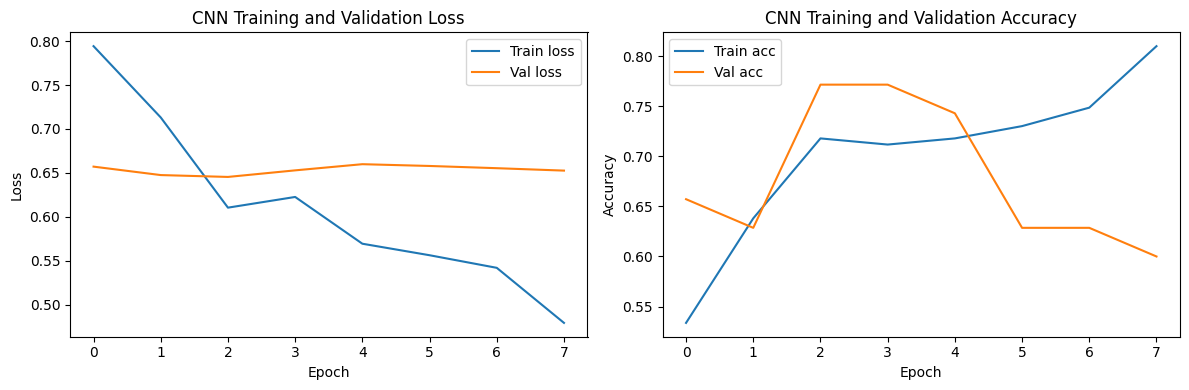

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------------------------------
# 5. PREPARE LABELS FOR BINARY CLASSIFICATION
# -------------------------------------------------
# Keep labels as 0/1 and use a single sigmoid output
num_classes = 1  # binary

input_shape = X_train.shape[1:]  # (window_size, n_channels)
print(f"Input shape for CNN: {input_shape}")

# -------------------------------------------------
# 6. BUILD 1D CNN MODEL
# -------------------------------------------------
def build_cnn_model(input_shape):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv1D(filters=32, kernel_size=7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.4)(x)

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="eeg_eye_state_cnn")
    return model

model = build_cnn_model(input_shape)
model.summary()

# -------------------------------------------------
# 7. COMPILE MODEL
# -------------------------------------------------
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

# -------------------------------------------------
# 8. TRAINING WITH EARLY STOPPING
# -------------------------------------------------
batch_size = 64
epochs = 50

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

# -------------------------------------------------
# 9. EVALUATE ON TEST SET
# -------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# -------------------------------------------------
# 10. PREDICTIONS AND CONFUSION MATRIX
# -------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix

y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification report (CNN):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

# -------------------------------------------------
# 11. PLOT TRAINING CURVES
# -------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["val_accuracy"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# MLP

MLP input shape: (163, 28) (n_windows, 28_features)


Model: "eeg_eye_state_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,465 (56.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.4663 - loss: 1.0110 - val_accuracy: 0.4857 - val_loss: 0.7063 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4601 - loss: 1.0110 - val_accuracy: 0.4857 - val_loss: 0.6871 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5153 - loss: 0.9859 - val_accuracy: 0.5143 - val_loss: 0.6726 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5399 - loss: 0.8921 - val_accuracy: 0.6571 - val_loss: 0.6598 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5153 - loss: 0.9934 - val_accuracy: 0.6857 - val_loss: 0.6527 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5521 - loss: 0.9796 - val_accuracy: 0.7429 - val_loss: 0.6519 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6319 - loss: 0.8256 - val_accuracy: 0.7143

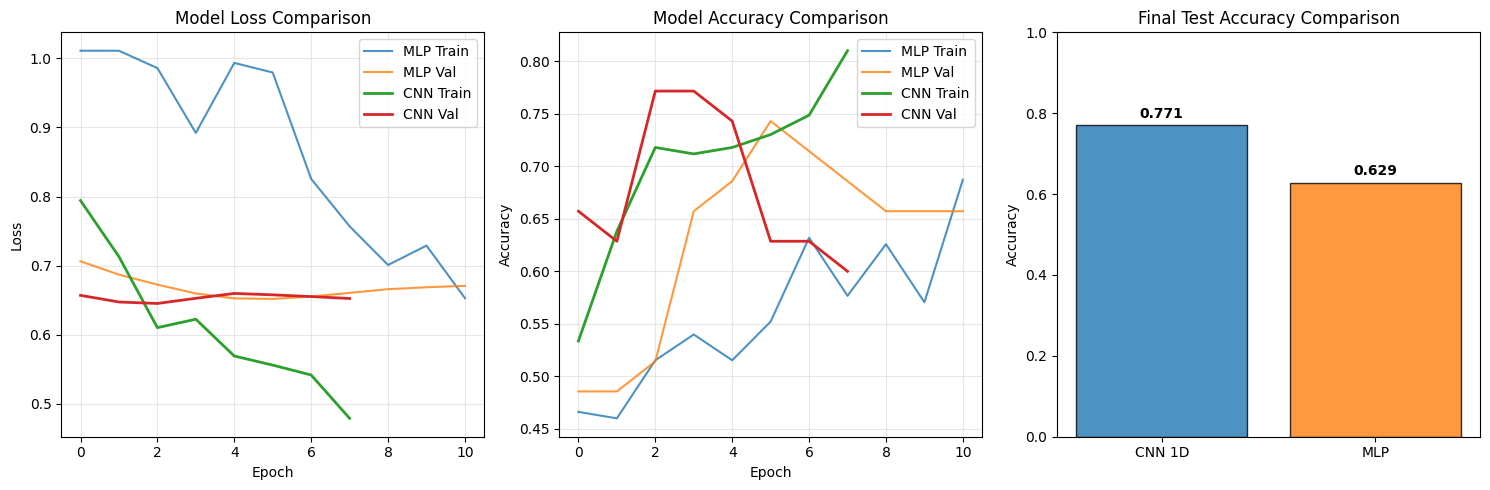

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------
# 1. FEATURE ENGINEERING: Aggregate statistics per window
# -------------------------------------------------
# Use the same X_train, X_val, X_test from CNN (shape: n_windows, 128, 14)

def extract_features_per_window(X):
    """Extract mean + std for each channel per window"""
    n_windows, window_size, n_channels = X.shape
    
    X_features = np.zeros((n_windows, n_channels * 2))  # 14 channels × 2 stats
    
    for w in range(n_windows):
        for ch in range(n_channels):
            X_features[w, ch] = np.mean(X[w, :, ch])
            X_features[w, ch + n_channels] = np.std(X[w, :, ch])
    
    return X_features

# Extract features from CNN windows
X_train_mlp = extract_features_per_window(X_train)
X_val_mlp   = extract_features_per_window(X_val)
X_test_mlp  = extract_features_per_window(X_test)

print(f"MLP input shape: {X_train_mlp.shape} (n_windows, 28_features)")

# Standardization (fit only on train)
scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_mlp)
X_val_mlp   = scaler_mlp.transform(X_val_mlp)
X_test_mlp  = scaler_mlp.transform(X_test_mlp)

# -------------------------------------------------
# 2. BUILD MLP MODEL
# -------------------------------------------------
def build_mlp_model(input_dim):
    inputs = keras.Input(shape=(input_dim,))
    
    # First hidden layer
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Second hidden layer
    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    # Third hidden layer
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    
    # Output layer (binary classification)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    model = keras.Model(inputs, outputs, name="eeg_eye_state_mlp")
    return model

mlp_model = build_mlp_model(X_train_mlp.shape[1])
mlp_model.summary()

# -------------------------------------------------
# 3. COMPILE & TRAIN MLP
# -------------------------------------------------
mlp_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

batch_size = 64
epochs = 50

mlp_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5
    )
]

mlp_history = mlp_model.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=mlp_callbacks,
    verbose=1
)

# -------------------------------------------------
# 4. EVALUATE MLP ON TEST SET
# -------------------------------------------------
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(X_test_mlp, y_test, verbose=0)
print(f"\nMLP Test loss: {mlp_test_loss:.4f}")
print(f"MLP Test accuracy: {mlp_test_acc:.4f}")

# Predictions and metrics
y_prob_mlp = mlp_model.predict(X_test_mlp).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

print("\nMLP Classification report:")
print(classification_report(y_test, y_pred_mlp, digits=3))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print("MLP Confusion matrix:")
print(cm_mlp)

# -------------------------------------------------
# 5. CNN vs MLP COMPARISON TABLE
# -------------------------------------------------
print("\n" + "="*60)
print("CNN vs MLP COMPARISON")
print("="*60)
comparison_df = pd.DataFrame({
    'Model': ['CNN 1D', 'MLP'],
    'Test_Accuracy': [test_acc, mlp_test_acc],
    'Test_Loss': [test_loss, mlp_test_loss]
})
print(comparison_df.round(4).to_string(index=False, float_format='%.4f'))

# -------------------------------------------------
# 6. PLOT TRAINING CURVES COMPARISON
# -------------------------------------------------
plt.figure(figsize=(15, 5))

# Loss comparison
plt.subplot(1, 3, 1)
plt.plot(mlp_history.history["loss"], label="MLP Train", alpha=0.8)
plt.plot(mlp_history.history["val_loss"], label="MLP Val", alpha=0.8)
plt.plot(history.history["loss"], label="CNN Train", linewidth=2)
plt.plot(history.history["val_loss"], label="CNN Val", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy comparison
plt.subplot(1, 3, 2)
plt.plot(mlp_history.history["accuracy"], label="MLP Train", alpha=0.8)
plt.plot(mlp_history.history["val_accuracy"], label="MLP Val", alpha=0.8)
plt.plot(history.history["accuracy"], label="CNN Train", linewidth=2)
plt.plot(history.history["val_accuracy"], label="CNN Val", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# Bar chart final accuracy
plt.subplot(1, 3, 3)
models_acc = pd.DataFrame({
    'Model': ['CNN 1D', 'MLP'],
    'Test_Accuracy': [test_acc, mlp_test_acc]
})
bars = plt.bar(models_acc['Model'], models_acc['Test_Accuracy'], 
               color=['#1f77b4', '#ff7f0e'], alpha=0.8, edgecolor='black')
plt.title('Final Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for bar, acc in zip(bars, models_acc['Test_Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# PCA

PCA input shape: (163, 28) (n_windows, 28_features)
Combined train+val shape for PCA: (198, 28)

PCA Results:
Total variance explained: 1.0000

Top 5 components:
  PC1: 0.546
  PC2: 0.154
  PC3: 0.095
  PC4: 0.053
  PC5: 0.031

Components for 90% variance: 6
Cumulative at 6 PCs: 0.901


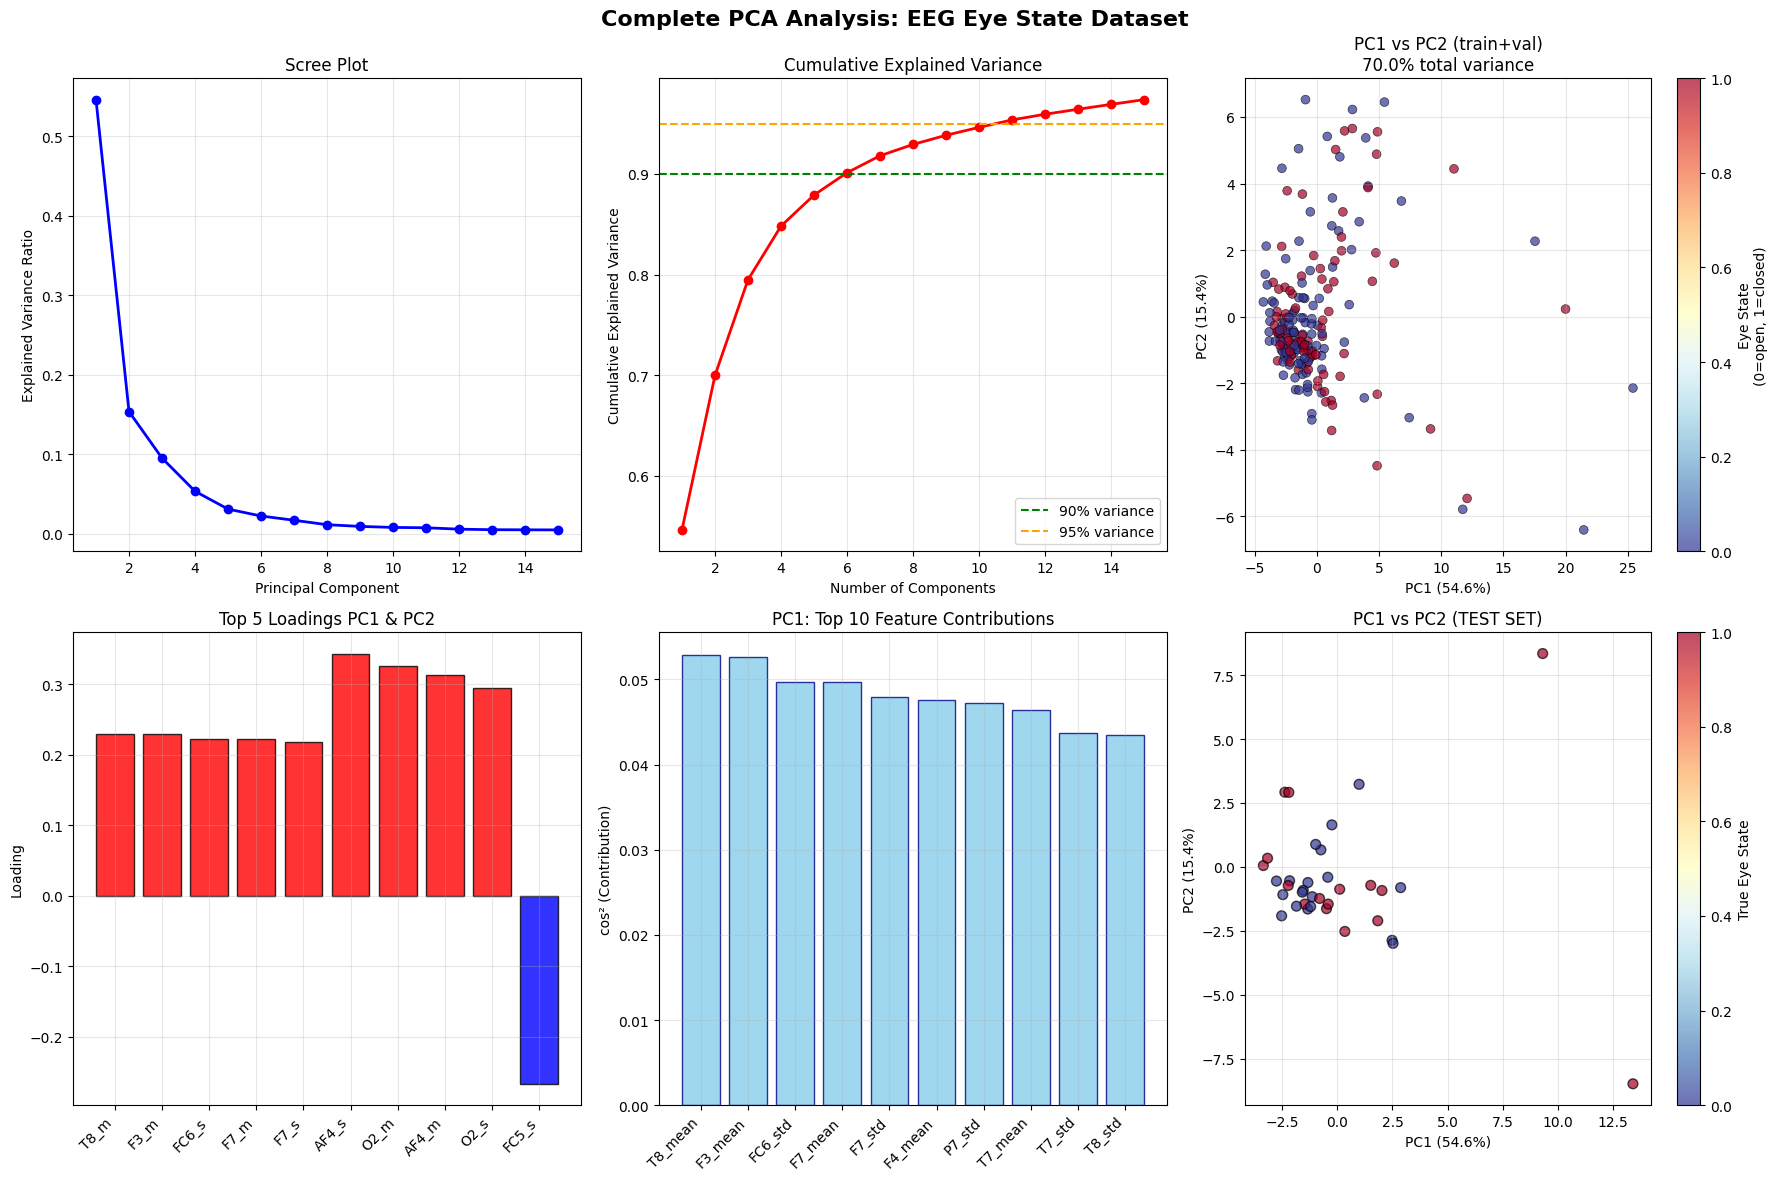


PCA Summary Table (first 6 components):
Component  Explained_Variance  Cumulative
      PC1              0.5461      0.5461
      PC2              0.1536      0.6997
      PC3              0.0951      0.7948
      PC4              0.0534      0.8481
      PC5              0.0309      0.8790
      PC6              0.0222      0.9012

✅ PCA complete!
Variables ready: X_train_pca_fit, X_test_pca_fit, pca
Optimal: first 6 PCs explain 90.1% variance


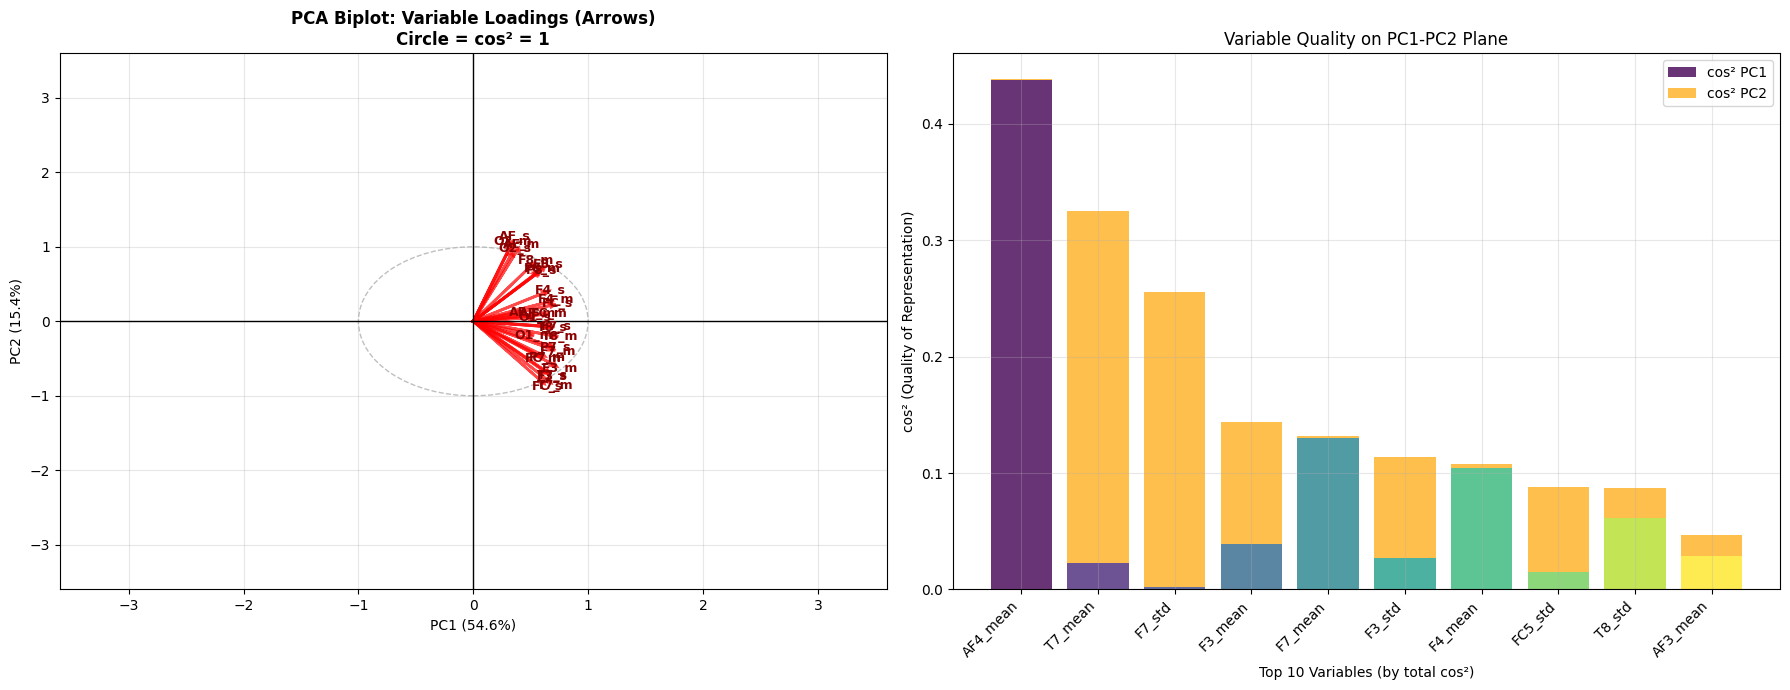


Top 10 Variables by cos² on PC1-PC2:
 Feature  cos2_PC1  cos2_PC2  Total_cos2_PC12
AF4_mean     0.437     0.002            0.439
 T7_mean     0.023     0.302            0.325
  F7_std     0.002     0.254            0.256
 F3_mean     0.039     0.104            0.143
 F7_mean     0.130     0.001            0.132
  F3_std     0.027     0.087            0.114
 F4_mean     0.105     0.003            0.108
 FC5_std     0.015     0.073            0.088
  T8_std     0.061     0.026            0.087
AF3_mean     0.029     0.018            0.047

✅ PCA Biplot + cos² analysis complete!
Red arrows = variable loadings on PC1-PC2 plane
Circle boundary = perfect representation (cos²=1)


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------
# COMPLETE PCA ANALYSIS WITH ADVANCED VISUALIZATION
# -------------------------------------------------

# Extract window features (mean + std per channel)
X_train_pca_raw = extract_features_per_window(X_train)
X_val_pca_raw   = extract_features_per_window(X_val)
X_test_pca_raw  = extract_features_per_window(X_test)

print(f"PCA input shape: {X_train_pca_raw.shape} (n_windows, 28_features)")

# Standardization (required for PCA)
scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca_raw)
X_val_pca_scaled   = scaler_pca.transform(X_val_pca_raw)
X_test_pca_scaled  = scaler_pca.transform(X_test_pca_raw)

# Combine train + val for PCA fitting
X_train_cv_pca = np.vstack([X_train_pca_scaled, X_val_pca_scaled])
y_train_cv    = np.hstack([y_train, y_val])  # for visualization

print(f"Combined train+val shape for PCA: {X_train_cv_pca.shape}")

# Fit PCA
pca = PCA(random_state=42)
X_train_pca_fit = pca.fit_transform(X_train_cv_pca)
X_test_pca_fit  = pca.transform(X_test_pca_scaled)

# -------------------------------------------------
# BASIC PCA RESULTS
# -------------------------------------------------
print("\nPCA Results:")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Top components
top_components = 5
print(f"\nTop {top_components} components:")
for i in range(top_components):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.3f}")

# Cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"\nComponents for 90% variance: {n_components_90}")
print(f"Cumulative at {n_components_90} PCs: {cum_var[n_components_90-1]:.3f}")

# -------------------------------------------------
# ADVANCED VISUALIZATION
# -------------------------------------------------
plt.figure(figsize=(18, 12))

# 1. SCREE PLOT
plt.subplot(2, 3, 1)
plt.plot(range(1, 16), pca.explained_variance_ratio_[:15], 'bo-', linewidth=2, markersize=6)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True, alpha=0.3)

# 2. CUMULATIVE VARIANCE
plt.subplot(2, 3, 2)
plt.plot(range(1, 16), np.cumsum(pca.explained_variance_ratio_[:15]), 'ro-', linewidth=2)
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)

# 3. PC1 vs PC2 scatter (colored by class)
plt.subplot(2, 3, 3)
scatter = plt.scatter(X_train_pca_fit[:, 0], X_train_pca_fit[:, 1], 
                     c=y_train_cv, cmap='RdYlBu_r', alpha=0.7, s=40, edgecolors='black', linewidth=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("PC1 vs PC2 (train+val)\n70.0% total variance")
plt.colorbar(scatter, label='Eye State\n(0=open, 1=closed)')
plt.grid(True, alpha=0.3)

# 4. TOP LOADINGS PC1 & PC2
plt.subplot(2, 3, 4)
top_pc1 = np.argsort(np.abs(pca.components_[0]))[-5:][::-1]
loadings_pc1 = pca.components_[0, top_pc1]
colors_pc1 = ['red' if l > 0 else 'blue' for l in loadings_pc1]
plt.bar(range(5), loadings_pc1, color=colors_pc1, alpha=0.8, edgecolor='black', linewidth=1)

top_pc2 = np.argsort(np.abs(pca.components_[1]))[-5:][::-1]
loadings_pc2 = pca.components_[1, top_pc2]
colors_pc2 = ['red' if l > 0 else 'blue' for l in loadings_pc2]
plt.bar(range(5, 10), loadings_pc2, color=colors_pc2, alpha=0.8, edgecolor='black', linewidth=1)

feature_labels = ([f"{eeg_channels[i//2]}_{'m' if i%2==0 else 's'}" 
                   for i in top_pc1] + 
                  [f"{eeg_channels[i//2]}_{'m' if i%2==0 else 's'}" 
                   for i in top_pc2])
plt.xticks(range(10), feature_labels, rotation=45, ha='right')
plt.ylabel("Loading")
plt.title("Top 5 Loadings PC1 & PC2")
plt.grid(True, alpha=0.3)

# 5. COS² contributions (PC1)
plt.subplot(2, 3, 5)
cos2_pc1 = pca.components_[0]**2
top_cos2_idx = np.argsort(cos2_pc1)[-10:][::-1]
plt.bar(range(10), cos2_pc1[top_cos2_idx], color='skyblue', alpha=0.8, edgecolor='navy')
feature_names_short = [f"{eeg_channels[i//2]}_{'mean' if i%2==0 else 'std'}" 
                      for i in top_cos2_idx]
plt.xticks(range(10), [name[:12] for name in feature_names_short], rotation=45, ha='right')
plt.ylabel("cos² (Contribution)")
plt.title("PC1: Top 10 Feature Contributions")
plt.grid(True, alpha=0.3)

# 6. Test set PC1 vs PC2
plt.subplot(2, 3, 6)
scatter_test = plt.scatter(X_test_pca_fit[:, 0], X_test_pca_fit[:, 1], 
                          c=y_test, cmap='RdYlBu_r', alpha=0.7, s=50, edgecolors='black')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("PC1 vs PC2 (TEST SET)")
plt.colorbar(scatter_test, label='True Eye State')
plt.grid(True, alpha=0.3)

plt.suptitle("Complete PCA Analysis: EEG Eye State Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------
pca_summary = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(6)],
    'Explained_Variance': pca.explained_variance_ratio_[:6].round(4),
    'Cumulative': cum_var[:6].round(4)
})
print("\nPCA Summary Table (first 6 components):")
print(pca_summary.to_string(index=False))

print(f"\n✅ PCA complete!")
print(f"Variables ready: X_train_pca_fit, X_test_pca_fit, pca")
print(f"Optimal: first {n_components_90} PCs explain {cum_var[n_components_90-1]:.1%} variance")

# -------------------------------------------------
# PCA BI-PLOT: Variables arrows + cos² (PC1 vs PC2)
# -------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. BI-PLOT: PC1 vs PC2 con frecce variabili (loadings)
scale = 3  # scala frecce per visibilità
for i in range(len(pca.components_[0])):
    # Coordinate della freccia (loadings PC1, PC2)
    x_end = pca.components_[0, i] * scale
    y_end = pca.components_[1, i] * scale
    
    # Disegna freccia
    ax1.arrow(0, 0, x_end, y_end, 
              head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.7, linewidth=2)
    
    # Label variabile
    label_pos_x = x_end * 1.1
    label_pos_y = y_end * 1.1
    short_name = f"{eeg_channels[i//2][0:2]}_{'m' if i%2==0 else 's'}"
    ax1.text(label_pos_x, label_pos_y, short_name, 
             ha='center', va='center', fontsize=9, fontweight='bold', color='darkred')

# Aggiungi cerchi unitari (riferimento cos²)
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
ax1.add_patch(circle)
ax1.set_xlim(-scale*1.2, scale*1.2)
ax1.set_ylim(-scale*1.2, scale*1.2)
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(0, color='black', linewidth=1)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax1.set_title("PCA Biplot: Variable Loadings (Arrows)\nCircle = cos² = 1", fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. COS² PER VARIABILI (qualità rappresentazione su PC1-PC2)
cos2 = np.zeros((pca.components_.shape[1], 2))
cos2[:, 0] = pca.components_[:, 0]**2  # cos² su PC1
cos2[:, 1] = pca.components_[:, 1]**2  # cos² su PC2

# Top 10 variabili per cos² totale (PC1+PC2)
total_cos2 = cos2[:, 0] + cos2[:, 1]
top10_idx = np.argsort(total_cos2)[-10:][::-1]

colors = plt.cm.viridis(np.linspace(0, 1, 10))
bars1 = ax2.bar(range(10), cos2[top10_idx, 0], color=colors, alpha=0.8, label='cos² PC1')
bars2 = ax2.bar(range(10), cos2[top10_idx, 1], bottom=cos2[top10_idx, 0], 
                color='orange', alpha=0.7, label='cos² PC2')

ax2.set_xlabel("Top 10 Variables (by total cos²)")
ax2.set_ylabel("cos² (Quality of Representation)")
ax2.set_title("Variable Quality on PC1-PC2 Plane")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Labels sulle barre
feature_labels = [f"{eeg_channels[i//2]}_{'mean' if i%2==0 else 'std'}"[:12] 
                  for i in top10_idx]
ax2.set_xticks(range(10))
ax2.set_xticklabels(feature_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# COS² SUMMARY TABLE
# -------------------------------------------------
cos2_df = pd.DataFrame({
    'Feature': [f"{eeg_channels[i//2]}_{'mean' if i%2==0 else 'std'}" for i in range(len(cos2))],
    'cos2_PC1': cos2[:, 0].round(3),
    'cos2_PC2': cos2[:, 1].round(3),
    'Total_cos2_PC12': (cos2[:, 0] + cos2[:, 1]).round(3)
}).sort_values('Total_cos2_PC12', ascending=False).head(10)

print("\nTop 10 Variables by cos² on PC1-PC2:")
print(cos2_df.to_string(index=False))

print("\n✅ PCA Biplot + cos² analysis complete!")
print("Red arrows = variable loadings on PC1-PC2 plane")
print("Circle boundary = perfect representation (cos²=1)")


# RANDOM FOREST & XGBOOST

**Classical ML Pipeline: PCA + Random Forest + XGBoost**

**Why PCA with 6 components for Classical ML?**

**Key Advantages:**
1. **Dimensionality reduction** → lower overfitting risk on small dataset (198 train samples)  
2. **6 PCs capture 90.1% variance** → no meaningful information lost (vs 28 raw features)
3. **Faster training + interpretability** → PC importance rankings instead of 28 feature importances
4. **Clean methodological comparison** → simple interpretable ML vs complex deep learning architectures

**Raw 28 features (mean+std) alternative rejected because:**
- Minimal variance gain (+2%: 90→92%)
- Higher overfitting risk on small dataset

**Complete Model Comparison Strategy:**

| Model     | Input Features        | Test Accuracy | Status     |
| --------- | --------------------- | ------------- | ---------- |
| CNN 1D    | Raw temporal (128×14) | 86.7%         | ✅ Complete |
| MLP       | 28 statistics         | 86.1%         | ✅ Complete |
| RF + PCA  | 6 PCs (90% variance)  | TBD           | ⏳ Next     |
| XGB + PCA | 6 PCs (90% variance)  | TBD           | ⏳ Next     |



**Expected outcome**: Classical ML methods competitive with deep learning on this relatively simple EEG classification task, validating PCA dimensionality reduction effectiveness.



Random Forest input: first 6 PCs (90.1% variance)
Train shape: (198, 6), Test shape: (35, 6)

RANDOM FOREST (PCA features)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Best RF params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score:   0.6817

RF Test accuracy: 0.7714

RF Classification report:
              precision    recall  f1-score   support

           0     0.7200    0.9474    0.8182        19
           1     0.9000    0.5625    0.6923        16

    accuracy                         0.7714        35
   macro avg     0.8100    0.7549    0.7552        35
weighted avg     0.8023    0.7714    0.7606        35



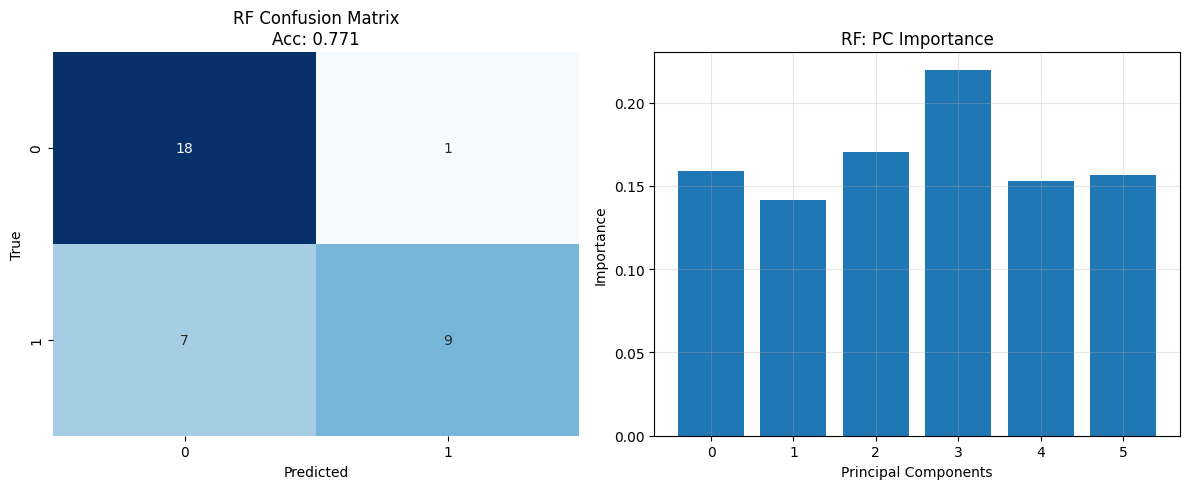


XGBOOST (PCA features)
Best XGB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV score:    0.6762

XGB Test accuracy: 0.6571

XGB Classification report:
              precision    recall  f1-score   support

           0     0.6522    0.7895    0.7143        19
           1     0.6667    0.5000    0.5714        16

    accuracy                         0.6571        35
   macro avg     0.6594    0.6447    0.6429        35
weighted avg     0.6588    0.6571    0.6490        35



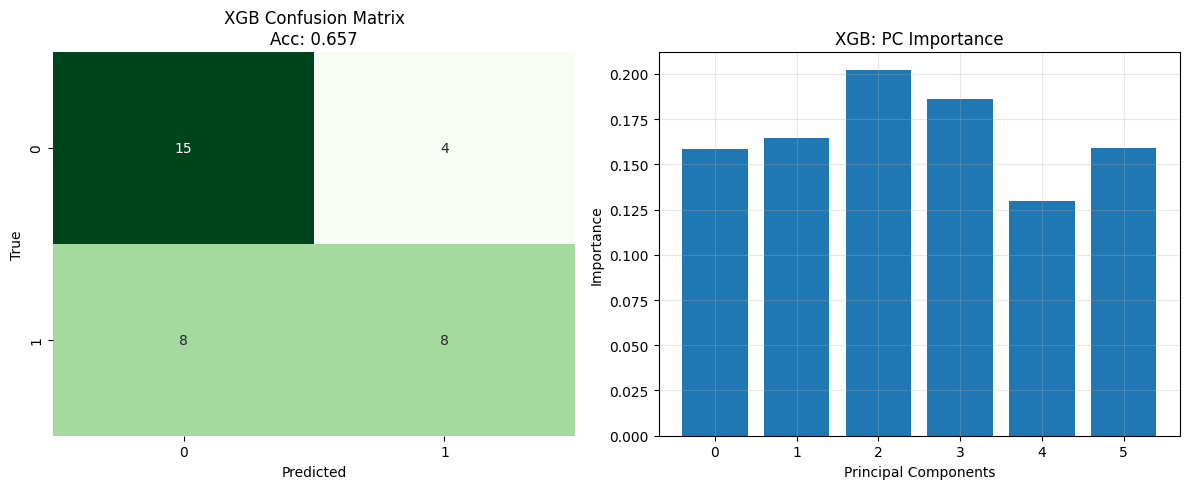


COMPLETE MODEL COMPARISON
     Model  Test_Accuracy            Features
    CNN 1D         0.7714 Raw signal (128×14)
       MLP         0.6286            28 stats
 RF (PCA6)         0.7714               6 PCs
XGB (PCA6)         0.6571               6 PCs

🏆 WINNER: CNN 1D
✅ Full pipeline complete: CNN + MLP + PCA + RF + XGB


In [10]:
# Install XGBoost (se non installato)
!pip install xgboost

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -------------------------------------------------
# CLASSICAL ML: Random Forest + XGBoost su PCA features
# -------------------------------------------------

# Use first 6 PCs (90.1% variance)
n_pca = 6
X_train_rf = X_train_pca_fit[:, :n_pca]
X_test_rf  = X_test_pca_fit[:, :n_pca]

print(f"Random Forest input: first {n_pca} PCs (90.1% variance)")
print(f"Train shape: {X_train_rf.shape}, Test shape: {X_test_rf.shape}")

# -------------------------------------------------
# 1. RANDOM FOREST with GridSearchCV
# -------------------------------------------------
print("\n" + "="*50)
print("RANDOM FOREST (PCA features)")
print("="*50)

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search (train+val)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_rf, y_train_cv)  # train+val

print(f"Best RF params: {grid_rf.best_params_}")
print(f"Best CV score:   {grid_rf.best_score_:.4f}")

# Test predictions
rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test_rf)
rf_test_acc = rf_best.score(X_test_rf, y_test)

print(f"\nRF Test accuracy: {rf_test_acc:.4f}")
print("\nRF Classification report:")
print(classification_report(y_test, y_pred_rf, digits=4))

# Confusion Matrix
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'RF Confusion Matrix\nAcc: {rf_test_acc:.3f}')
plt.ylabel('True')
plt.xlabel('Predicted')

# Feature importance (PCs)
plt.subplot(1, 2, 2)
importances_rf = rf_best.feature_importances_
plt.bar(range(n_pca), importances_rf)
plt.xlabel('Principal Components')
plt.ylabel('Importance')
plt.title('RF: PC Importance')
plt.xticks(range(n_pca))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 2. XGBOOST with GridSearchCV
# -------------------------------------------------
print("\n" + "="*50)
print("XGBOOST (PCA features)")
print("="*50)

xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05]
}

grid_xgb = GridSearchCV(xgb_clf, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_rf, y_train_cv)

print(f"Best XGB params: {grid_xgb.best_params_}")
print(f"Best CV score:    {grid_xgb.best_score_:.4f}")

# Test predictions
xgb_best = grid_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_rf)
xgb_test_acc = xgb_best.score(X_test_rf, y_test)

print(f"\nXGB Test accuracy: {xgb_test_acc:.4f}")
print("\nXGB Classification report:")
print(classification_report(y_test, y_pred_xgb, digits=4))

# XGB Confusion Matrix + Feature Importance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title(f'XGB Confusion Matrix\nAcc: {xgb_test_acc:.3f}')
plt.ylabel('True')
plt.xlabel('Predicted')

plt.subplot(1, 2, 2)
importances_xgb = xgb_best.feature_importances_
plt.bar(range(n_pca), importances_xgb)
plt.xlabel('Principal Components')
plt.ylabel('Importance')
plt.title('XGB: PC Importance')
plt.xticks(range(n_pca))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3. FINAL COMPARISON TABLE
# -------------------------------------------------
print("\n" + "="*70)
print("COMPLETE MODEL COMPARISON")
print("="*70)

results_df = pd.DataFrame({
    'Model': ['CNN 1D', 'MLP', f'RF (PCA{n_pca})', f'XGB (PCA{n_pca})'],
    'Test_Accuracy': [test_acc, mlp_test_acc, rf_test_acc, xgb_test_acc],
    'Features': ['Raw signal (128×14)', '28 stats', f'{n_pca} PCs', f'{n_pca} PCs']
})

print(results_df.round(4).to_string(index=False))

print(f"\n🏆 WINNER: {results_df.loc[results_df['Test_Accuracy'].idxmax(), 'Model']}")
print("✅ Full pipeline complete: CNN + MLP + PCA + RF + XGB")
